 data_exploratory.py

Shape of dataset: (235795, 56)

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubD

C:\Users\HP\AppData\Local\Temp\ipykernel_16724\1417260017.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette="Set2")


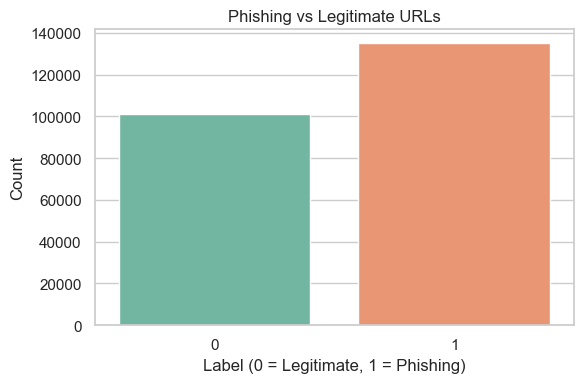

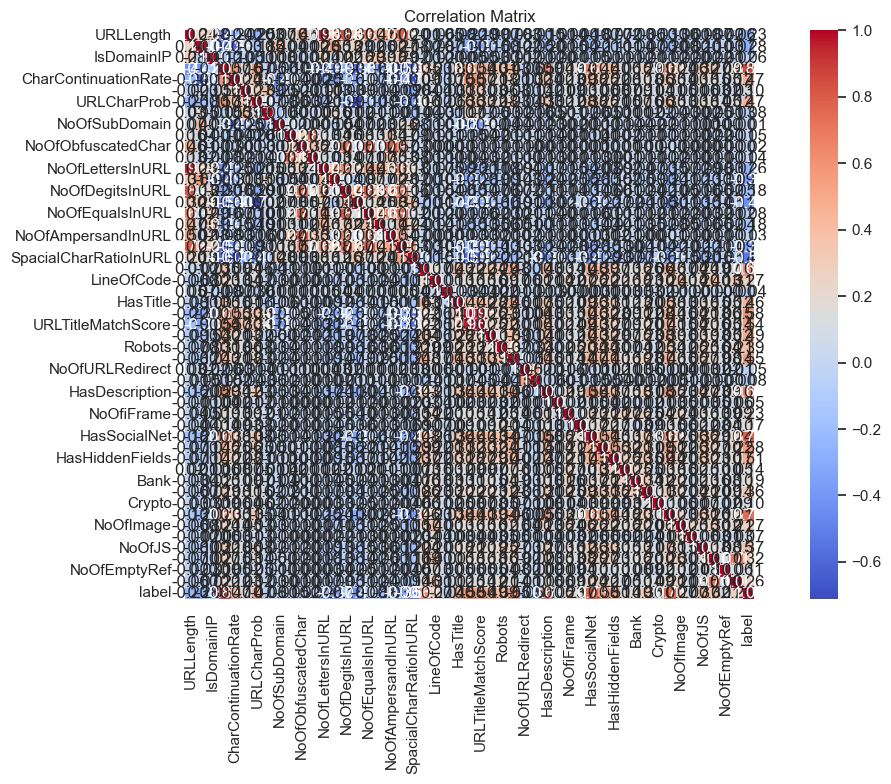

In [3]:
# 01_data_exploration.ipynb

# 📌 Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 📌 Display settings
pd.set_option("display.max_columns", 100)
sns.set(style="whitegrid")

# 📌 Load Dataset
data_path = "PhiUSIIL_Phishing_URL_Dataset.csv"

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
else:
    raise FileNotFoundError(f"Dataset not found at {data_path}")

# 📌 Basic Info
print("Shape of dataset:", df.shape)
print("\nData types and non-null counts:")
print(df.info())
print("\nFirst few rows:")
print(df.head())

# 📌 Check for Missing Values
print("\nMissing values:")
print(df.isnull().sum())

# 📌 Unique Values per Column
print("\nUnique values per column:")
print(df.nunique())

# 📌 Class Distribution
print("\nTarget variable distribution:")
print(df['label'].value_counts())

# 📊 Plot: Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette="Set2")
plt.title("Phishing vs Legitimate URLs")
plt.xlabel("Label (0 = Legitimate, 1 = Phishing)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 📊 Plot: Correlation Matrix (for numeric features only)
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [4]:
import pandas as pd

# Load your dataset
df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

# Drop unnecessary columns (only if you're sure they're not useful)
columns_to_drop = ['FILENAME']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Handle missing values
# Option 1: Drop rows with any missing values
df = df.dropna()

# Option 2 (alternative): Fill missing values (customize as needed)
# df = df.fillna(method='ffill')  # Forward fill
# df = df.fillna(0)               # Or fill with 0

# Identify categorical features
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical features:")
for col in categorical_columns:
    print(f"- {col}")


Categorical features:
- URL
- Domain
- TLD
- Title


In [5]:
import pandas as pd

# Load your dataset
df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

# Show missing values per column
print("\n📊 Missing Values per Column:")
print(df.isnull().sum())

# Classify features by data type
categorical_cols = ['URL', 'Domain', 'TLD', 'Title']
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime', 'datetime64']).columns.tolist()

# Exclude known categoricals from numericals if mistakenly inferred
numerical_cols = [col for col in numerical_cols if col not in categorical_cols]

print("\n🔠 Categorical Features:")
for col in categorical_cols:
    print(f"- {col}")

print("\n🔢 Numerical Features:")
for col in numerical_cols:
    print(f"- {col}")

print("\n📅 DateTime Features:")
for col in datetime_cols:
    print(f"- {col}")

# OPTIONAL: Handle missing values
# df = df.dropna()  # Drop rows with any missing values
# OR fill missing values:
# df = df.fillna(method='ffill')

# OPTIONAL: Drop columns NOT needed (leave out the important categoricals)
columns_to_drop = ['FILENAME']  # Keep URL, Domain, TLD, Title
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])



📊 Missing Values per Column:
FILENAME                      0
URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitl

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from tqdm import tqdm


# === Define features and target ===
categorical_features = ['URL', 'Domain', 'TLD', 'Title']
numerical_features = df.drop(columns=categorical_features + ['label']).columns.tolist()
target = 'label'

y = df[target]
X = df.drop(columns=[target])

# === Preprocessing pipeline ===
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# === Base learners ===
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
mlp_clf = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)

# === Hybrid model (voting of base learners) ===
hybrid = VotingClassifier(
    estimators=[
        ('rf', rf_clf),
        ('xgb', xgb_clf),
        ('mlp', mlp_clf)
    ],
    voting='soft'
)

# === Stratified K-Fold Setup ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta_features_train = np.zeros((X.shape[0], 4))  # 3 base + 1 hybrid

# === Loop through folds with tqdm progress bar ===
print("\n📦 Running Stratified K-Fold Training:")
for fold, (train_idx, val_idx) in tqdm(enumerate(skf.split(X, y), 1), total=5, desc="Training Folds"):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    X_train_trans = preprocessor.fit_transform(X_train)
    X_val_trans = preprocessor.transform(X_val)

    # Train base models
    rf_clf.fit(X_train_trans, y_train)
    xgb_clf.fit(X_train_trans, y_train)
    mlp_clf.fit(X_train_trans, y_train)
    hybrid.fit(X_train_trans, y_train)

    # Meta features = prediction probabilities
    meta_features_train[val_idx, 0] = rf_clf.predict_proba(X_val_trans)[:, 1]
    meta_features_train[val_idx, 1] = xgb_clf.predict_proba(X_val_trans)[:, 1]
    meta_features_train[val_idx, 2] = mlp_clf.predict_proba(X_val_trans)[:, 1]
    meta_features_train[val_idx, 3] = hybrid.predict_proba(X_val_trans)[:, 1]

# === Meta-model training ===
print("\n🚀 Training Final Meta-Model (XGBClassifier)...")
meta_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
meta_model.fit(meta_features_train, y)

# === Final evaluation ===
print("\n🎯 Final Stacked Model Performance:")
meta_preds = meta_model.predict(meta_features_train)
print(classification_report(y, meta_preds))



📦 Running Stratified K-Fold Training:


Training Folds:   0%|          | 0/5 [01:55<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
data = df.copy()
# Convert categorical columns to category dtype
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# === 1. Load and Copy Dataset ===
# df = pd.read_csv('your_dataset.csv')  # Optional: load if not already loaded
#data = df.copy()

# === 2. Drop Unused Columns (if not needed for tracking/logging) ===
#drop_cols = ['FILENAME']  # Keep URL/Title if needed for explainability/logging
#data = data.drop(columns=drop_cols)

# === 3. Split into Features and Labels ===
X = data.drop(columns=['label'])
y = data['label']

# === 4. Identify Feature Types ===
categorical_features = ['URL', 'Domain', 'TLD', 'Title']
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.difference(categorical_features)

# === 5. Define Preprocessing Pipelines ===

# Numeric: fill missing with mean + scale
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Categorical: fill missing with 'unknown' + one-hot encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

# === 6. Create Final Pipeline ===
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# === 7. Split Data ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# === 8. Train ===
model.fit(X_train, y_train)

# === 9. Evaluate ===
y_pred = model.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("\n🔍 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


KeyboardInterrupt: 

full implementation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from tqdm import tqdm
import joblib

# === Load Dataset ===
df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")  # replace with your dataset
target = 'label'
# OPTIONAL: Drop columns NOT needed (leave out the important categoricals)
columns_to_drop = ['FILENAME']  # Keep URL, Domain, TLD, Title
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
categorical_features = ['URL', 'Domain', 'TLD', 'Title']
numerical_features = df.drop(columns=categorical_features + [target]).columns.tolist()

X = df.drop(columns=[target])
y = df[target]

# === Split into Train and Test ===
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# === Preprocessor ===
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# === Base Models ===
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(use_label_encoder=True, eval_metric='logloss', random_state=42)
#mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=3, random_state=42)

# === Hybrid Model ===
hybrid = VotingClassifier(
    estimators=[("rf", rf), ("xgb", xgb)], #, ("mlp", mlp)],
    voting="soft"
)

# === Create Meta-Feature Matrix via Stratified K-Fold ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta_features = np.zeros((X_train_full.shape[0], 4))  # 3 base + 1 hybrid

print("\n📦 Creating meta-features via StratifiedKFold:")
for fold, (train_idx, val_idx) in tqdm(enumerate(skf.split(X_train_full, y_train_full), 1), total=5):
    X_train, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_train, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc = preprocessor.transform(X_val)

    print("Random Forest")
    rf.fit(X_train_proc, y_train)
    print("XGBoost")
    xgb.fit(X_train_proc, y_train)
    print("multi Perceptron model")
    #mlp.fit(X_train_proc, y_train)
    print("hybrid model")
    hybrid.fit(X_train_proc, y_train)

    meta_features[val_idx, 0] = rf.predict_proba(X_val_proc)[:, 1]
    meta_features[val_idx, 1] = xgb.predict_proba(X_val_proc)[:, 1]
    #meta_features[val_idx, 2] = mlp.predict_proba(X_val_proc)[:, 1]
    meta_features[val_idx, 3] = hybrid.predict_proba(X_val_proc)[:, 1]

# === Train Final Meta-Model ===
meta_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
meta_model.fit(meta_features, y_train_full)

# === Predict on Test Data ===
print("\n🚀 Evaluating on Test Set")
X_test_proc = preprocessor.transform(X_test)

# Train final base models on all train data
rf.fit(preprocessor.transform(X_train_full), y_train_full)
xgb.fit(preprocessor.transform(X_train_full), y_train_full)
#mlp.fit(preprocessor.transform(X_train_full), y_train_full)
hybrid.fit(preprocessor.transform(X_train_full), y_train_full)

meta_test = np.column_stack([
    rf.predict_proba(X_test_proc)[:, 1],
    xgb.predict_proba(X_test_proc)[:, 1],
    #mlp.predict_proba(X_test_proc)[:, 1],
    hybrid.predict_proba(X_test_proc)[:, 1]
])

final_preds = meta_model.predict(meta_test)

# === Evaluation ===
print("\n📊 Classification Report:")
print(classification_report(y_test, final_preds))

print("\n🧩 Confusion Matrix:")
cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# === ROC/AUC Curves ===
def plot_roc_auc(models, labels, X_proc, y_true):
    plt.figure(figsize=(10, 7))
    for model, label in zip(models, labels):
        proba = model.predict_proba(X_proc)[:, 1]
        fpr, tpr, _ = roc_curve(y_true, proba)
        auc = roc_auc_score(y_true, proba)
        plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
    plt.title("ROC Curves")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()

print("\n📈 ROC Curves:")
plot_roc_auc(
    [rf, xgb, hybrid, meta_model],
    ["Random Forest", "XGBoost", "Hybrid Ensemble", "Meta-Stack (XGB)"],
    meta_test, y_test
)

# === Save the pipeline and meta model ===
print("\n💾 Saving models and preprocessor...")
joblib.dump(preprocessor, "preprocessor.joblib")
joblib.dump(rf, "rf_model.joblib")
joblib.dump(xgb, "xgb_model.joblib")
#joblib.dump(mlp, "mlp_model.joblib")
joblib.dump(hybrid, "hybrid_ensemble.joblib")
joblib.dump(meta_model, "meta_stacked_model.joblib")

print("✅ All models saved successfully.")



📦 Creating meta-features via StratifiedKFold:


  0%|          | 0/5 [00:00<?, ?it/s]

Random Forest
XGBoost


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:07:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


multi Perceptron model
hybrid model


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:36:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
 20%|██        | 1/5 [50:08<3:20:32, 3008.21s/it]

Random Forest


 20%|██        | 1/5 [51:44<3:26:57, 3104.40s/it]


[LightGBM] [Info] Number of positive: 107880, number of negative: 80756
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.413489 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8703
[LightGBM] [Info] Number of data points in the train set: 188636, number of used features: 671
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.571895 -> initscore=0.289587
[LightGBM] [Info] Start training from score 0.289587
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159


🧩 Confusion Matrix:


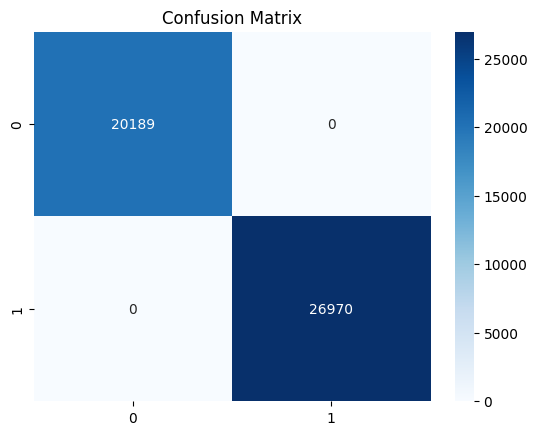


🎯 ROC AUC Score: 1.0000
✅ Model saved as phishing_detection_model.joblib


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# === Load Dataset ===
df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

# Drop unnecessary columns
df.drop(columns=['FILENAME'], inplace=True)

# Define target and features
target = 'label'
df.dropna(subset=[target], inplace=True)

# Optional: Drop 'URL' due to very high cardinality
categorical_features = ['Domain', 'TLD']
text_feature = 'Title'

numerical_features = df.drop(columns=categorical_features + [text_feature, target]).select_dtypes(include=np.number).columns.tolist()

X = df.drop(columns=[target])
y = df[target]

# === Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# === Preprocessing Pipeline ===
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features),
    ('text', TfidfVectorizer(max_features=500), 'Title')
])

# === Model Pipeline ===
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(random_state=42))
])

# === Train ===
model.fit(X_train, y_train)

# === Predict & Evaluate ===
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("\n🧩 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print(f"\n🎯 ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# === Save the model ===
joblib.dump(model, "phishing_detection_model.joblib")
print("✅ Model saved as phishing_detection_model.joblib")


⏳ Training XGBoost...


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:53:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost training done.
⏳ Training LightGBM...
[LightGBM] [Info] Number of positive: 107880, number of negative: 80756
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 4.436077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8958
[LightGBM] [Info] Number of data points in the train set: 188636, number of used features: 672
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.571895 -> initscore=0.289587
[LightGBM] [Info] Start training from score 0.289587
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
✅ LightGBM training done.

📊 XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.0

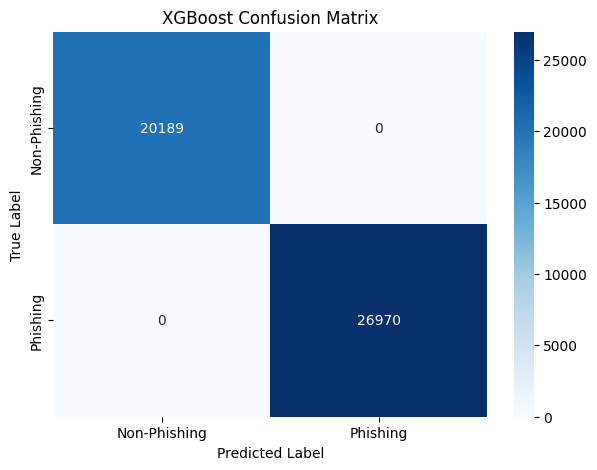

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



📊 LightGBM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

🎯 LightGBM ROC AUC Score: 1.0000


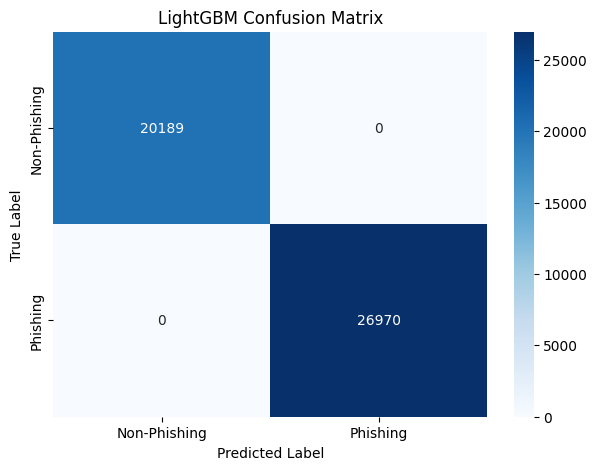

💾 Models saved: phishing_model_xgb.joblib and phishing_model_lgbm.joblib


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import hashlib

# === Load Dataset ===
df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")
df.drop(columns=['FILENAME'], inplace=True)
df.dropna(subset=['label'], inplace=True)

# === Define target and features ===
target = 'label'
categorical_features = ['Domain', 'TLD']
text_feature = 'Title'
hash_feature = 'URL'

# Identify numerical features dynamically
numerical_features = df.drop(columns=[target] + categorical_features + [text_feature, hash_feature]).select_dtypes(include=np.number).columns.tolist()

# Define features and target
X = df.drop(columns=[target])
y = df[target]

# === Hashing function ===
def hash_url_column(X):
    """Hash the URL column to a numerical representation."""
    # Ensure X is converted to a NumPy array before applying ravel()
    X = np.array(X).ravel()  
    return np.array([int(hashlib.sha256(url.encode('utf-8')).hexdigest(), 16) % (10 ** 8) for url in X]).reshape(-1, 1)

# Apply FunctionTransformer for URL hashing
hashing_transformer = FunctionTransformer(hash_url_column, validate=False)

# === Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# === Common Preprocessor ===
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),  # Numerical features scaling
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features),  # Categorical encoding
    ('text', TfidfVectorizer(max_features=500), 'Title'),  # Text feature vectorization
    ('urlhash', hashing_transformer, ['URL'])  # URL hashing transformer
])

# === Model Pipelines ===
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))  # XGBoost classifier
])

lgbm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(random_state=42))  # LightGBM classifier
])

# === Train both models ===
print("⏳ Training XGBoost...")
xgb_model.fit(X_train, y_train)
print("✅ XGBoost training done.")

print("⏳ Training LightGBM...")
lgbm_model.fit(X_train, y_train)
print("✅ LightGBM training done.")

# === Evaluation Function ===
def evaluate_model(name, model):
    """Evaluate the model with classification report, ROC AUC score, and confusion matrix."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # Get probabilities for ROC AUC

    print(f"\n📊 {name} Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"🎯 {name} ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Phishing', 'Phishing'], yticklabels=['Non-Phishing', 'Phishing'])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# === Evaluate both models ===
evaluate_model("XGBoost", xgb_model)
evaluate_model("LightGBM", lgbm_model)

# === Save models ===
joblib.dump(xgb_model, "phishing_model_xgb.joblib")
joblib.dump(lgbm_model, "phishing_model_lgbm.joblib")
print("💾 Models saved: phishing_model_xgb.joblib and phishing_model_lgbm.joblib")


In [ ]:
import pandas as pd
import numpy as np
import joblib
import hashlib
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# === Load Test Dataset ===
df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")
df.drop(columns=['FILENAME'], inplace=True)
df.dropna(subset=['label'], inplace=True)

# === Define Features ===
target = 'label'
categorical_features = ['Domain', 'TLD']
text_feature = 'Title'
hash_feature = 'URL'

numerical_features = df.drop(columns=[target] + categorical_features + [text_feature, hash_feature]).select_dtypes(include=np.number).columns.tolist()

X = df.drop(columns=[target])
y = df[target]

# === Load Model ===
# Choose which model to load
model = joblib.load("phishing_model_xgb.joblib")
# model = joblib.load("phishing_model_lgbm.joblib")  # Uncomment to test LightGBM instead

# === Predict and Evaluate ===
y_pred = model.predict(X)
y_proba = model.predict_proba(X)[:, 1]

print("📊 Classification Report:")
print(classification_report(y, y_pred))

print(f"🎯 ROC AUC Score: {roc_auc_score(y, y_proba):.4f}")

# === Confusion Matrix ===
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Non-Phishing', 'Phishing'], yticklabels=['Non-Phishing', 'Phishing'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


ModuleNotFoundError: No module named 'features'